In [1]:
import pandas as pd
diabetic = pd.read_csv("diabetic_data.csv")
diabetic.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
diabetic.shape

(101766, 50)

In [3]:
diabetic.isnull().sum() #detects missing values like none or NaN

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [4]:
diabetic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
diabetic.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [6]:
diabetic.duplicated().sum()

np.int64(0)

In [7]:
#are there duplicated patients within database
diabetic['patient_nbr'].duplicated().sum()

#so - duplicate patients for different encounters.

np.int64(30248)

In [8]:
#what abt encounter
diabetic['encounter_id'].duplicated().any()

np.False_

In [9]:
#lets look at all the unique values of categorical variables

for catcol in diabetic.select_dtypes(include="object").columns:
    print(diabetic[catcol].value_counts())
    print()

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

payer_code
?     40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64

medical_specialty
? 

In [10]:
diabetic['medical_specialty'].unique()

array(['Pediatrics-Endocrinology', '?', 'InternalMedicine',
       'Family/GeneralPractice', 'Cardiology', 'Surgery-General',
       'Orthopedics', 'Gastroenterology',
       'Surgery-Cardiovascular/Thoracic', 'Nephrology',
       'Orthopedics-Reconstructive', 'Psychiatry', 'Emergency/Trauma',
       'Pulmonology', 'Surgery-Neuro',
       'Obsterics&Gynecology-GynecologicOnco', 'ObstetricsandGynecology',
       'Pediatrics', 'Hematology/Oncology', 'Otolaryngology',
       'Surgery-Colon&Rectal', 'Pediatrics-CriticalCare', 'Endocrinology',
       'Urology', 'Psychiatry-Child/Adolescent', 'Pediatrics-Pulmonology',
       'Neurology', 'Anesthesiology-Pediatric', 'Radiology',
       'Pediatrics-Hematology-Oncology', 'Psychology', 'Podiatry',
       'Gynecology', 'Oncology', 'Pediatrics-Neurology',
       'Surgery-Plastic', 'Surgery-Thoracic',
       'Surgery-PlasticwithinHeadandNeck', 'Ophthalmology',
       'Surgery-Pediatric', 'Pediatrics-EmergencyMedicine',
       'PhysicalMedicineandRe

In [11]:
diabetic['diag_1'].unique()

array(['250.83', '276', '648', '8', '197', '414', '428', '398', '434',
       '250.7', '157', '518', '999', '410', '682', '402', '737', '572',
       'V57', '189', '786', '427', '996', '277', '584', '462', '473',
       '411', '174', '486', '998', '511', '432', '626', '295', '196',
       '250.6', '618', '182', '845', '423', '808', '250.4', '722', '403',
       '250.11', '784', '707', '440', '151', '715', '997', '198', '564',
       '812', '38', '590', '556', '578', '250.32', '433', 'V58', '569',
       '185', '536', '255', '250.13', '599', '558', '574', '491', '560',
       '244', '250.03', '577', '730', '188', '824', '250.8', '332', '562',
       '291', '296', '510', '401', '263', '438', '70', '250.02', '493',
       '642', '625', '571', '738', '593', '250.42', '807', '456', '446',
       '575', '250.41', '820', '515', '780', '250.22', '995', '235',
       '250.82', '721', '787', '162', '724', '282', '514', 'V55', '281',
       '250.33', '530', '466', '435', '250.12', 'V53', '789', '

In [12]:
#STAGE1 : DEFINING DATASET AND FINALIZING COHORT TO BE USED
#Step 1.1 - remove same patient with duplicate encounters - use only their first encounter
diabetic_cleandf = diabetic.copy()
diabetic_cleandf = diabetic_cleandf.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first")


In [13]:
#sanity check to see if duplicate patient_nbr
diabetic_cleandf.duplicated().sum()

np.int64(0)

In [14]:
#Now we have 1 encounter per patient.

#Step 1.2 - remove encounters that ended in death based on discharge_disposition_id

hospice_or_death_ids = {11, 13, 14, 19, 20, 21}
diabetic_cleandf = diabetic_cleandf[~diabetic_cleandf['discharge_disposition_id'].isin(hospice_or_death_ids)]

#Encounters ending in death or hospice disposition were excluded because subsequent hospital readmission is not an equivalent or 
#clinically meaningful outcome for these patients.


In [15]:
#Step 1.3 - remove weight (97% missing), patient_nbr (identifier), payer_code (irrelevant)
diabetic_cleandf = diabetic_cleandf.drop(["encounter_id", "patient_nbr", "payer_code"], axis=1)

In [16]:
#Step 1.4 - Replace ? with NaN
import numpy as np

diabetic_cleandf = diabetic_cleandf.replace("?", np.nan)

In [17]:
    #quick sanity check
(diabetic_cleandf == "?").sum().sum()

np.int64(0)

In [18]:
diabetic_cleandf.shape #so now we're working with 69,973 with 46 features

(69973, 47)

In [19]:
#Step 1.5 - Feature selection
    #Step 1.5.1. ICD-9 diagnosis group - using published ICD-9 mapping to group diagnoses (diag_1, diag_2, diag_3)
def group_diagnosis(icd_code):
    if pd.isna(icd_code):
        return "Unknown"
        
    if str(icd_code).startswith(("V", "E")): #if V and E codes dont fit the numeric ranges
        return "Other"

    try: #"try": attempt this code and if a specific error happens, this is how to handle it
        icd_code = float(icd_code) #float forces the code into decimal form. if conversion works, continue normally
    except ValueError: #e.g. V57 would raise a value-error and continue instead of program stopping
        return "Other"


    if 390<= icd_code <=459 or icd_code ==785:
        return "Circulatory"

    if 460<= icd_code <=519 or icd_code == 786:
        return "Respiratory"

    if 520<= icd_code <=579 or icd_code== 787:
        return "Digestive"

    if 250 <=icd_code <251 :
        return "Diabetes" #All 250.xx is Diabetes

    if 800<= icd_code <=999 :
        return "Injury"

    if 710<= icd_code <=739:
        return "Musculoskeletal"

    if 580<= icd_code <= 629 or icd_code == 788 :
        return "Genitourinary"

    if 140<= icd_code<=239 :
        return "Neoplasms"

    else :
        return "Other"
        
for col in ["diag_1", "diag_2", "diag_3"]:
    diabetic_cleandf[col + "_group"] = diabetic_cleandf[col].apply(group_diagnosis)

#diabetic_cleandf["diag_1_group"] = diabetic_cleandf["diag_1"].apply(group_diagnosis)
#diabetic_cleandf["diag_2_group"] = diabetic_cleandf["diag_2"].apply(group_diagnosis)
#diabetic_cleandf["diag_3_group"] = diabetic_cleandf["diag_3"].apply(group_diagnosis)
    
diabetic_cleandf = diabetic_cleandf.drop(["diag_1", "diag_2", "diag_3"], axis = 1) #drop original colums
    


In [20]:
 #Step 1.5.2.: Keep major "medical_Specialty" groups and collapse others into "Other"
major_groups = ["Cardiology", "Family/GeneralPractice", "InternalMedicine", "Surgery-General"]

def specialty_groups(specialty):
    if pd.isna(specialty):
        return "Unknown"
    elif specialty in major_groups:
        return specialty
    else:
        return "Other"

diabetic_cleandf["medical_specialty"] = (diabetic_cleandf["medical_specialty"].apply(specialty_groups))


In [21]:
    #Step 1.5.3. Add two more columns - "sumtotal_diabetes_meds" and "num_med_changes"

drug_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide','pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

diabetic_cleandf["sumtotal_diabetes_meds"] = (diabetic_cleandf[drug_cols] != "No").sum(axis=1) #axis=0 would answer how many patients are taking each drug
                #(diabetic_cleandf[drug_cols] != "No") returns a boolean array

diabetic_cleandf["num_med_changes"]= (diabetic_cleandf[drug_cols].isin(["Up", "Down"])).sum(axis=1)
    #"change" only tells you if some change happened or not, now we know how MANY changes were done

In [22]:
diabetic_cleandf.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,diag_1_group,diag_2_group,diag_3_group,sumtotal_diabetes_meds,num_med_changes
8,Caucasian,Female,[80-90),NaN,2,1,4,13,Unknown,68,...,No,No,Ch,Yes,NO,Circulatory,Circulatory,Other,2,0
9,Caucasian,Female,[90-100),NaN,3,3,4,12,InternalMedicine,33,...,No,No,Ch,Yes,NO,Circulatory,Neoplasms,Respiratory,2,0
4,Caucasian,Male,[40-50),NaN,1,1,7,1,Unknown,51,...,No,No,Ch,Yes,NO,Neoplasms,Neoplasms,Diabetes,2,0
10,AfricanAmerican,Female,[40-50),NaN,1,1,7,9,Unknown,47,...,No,No,No,Yes,>30,Diabetes,Circulatory,Injury,1,0
5,Caucasian,Male,[50-60),NaN,2,1,2,3,Unknown,31,...,No,No,No,Yes,>30,Circulatory,Circulatory,Diabetes,1,0


In [23]:
print(f"The final cohort has {diabetic_cleandf.shape[0]} rows and {diabetic_cleandf.shape[1]} features")
print(f"Class Balance\n : {diabetic_cleandf["readmitted"].value_counts()}")

The final cohort has 69973 rows and 49 features
Class Balance
 : readmitted
NO     41474
>30    22222
<30     6277
Name: count, dtype: int64


In [24]:
#STAGE 2 : TRAIN-TEST SPLIT AND EDA

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

    #Step 2.1 : Define Target
X= diabetic_cleandf.drop("readmitted", axis=1)
y= diabetic_cleandf["readmitted"].map({"<30":1, ">30" : 0, "NO" : 0})


In [25]:
    #quick sanity check for y
y.value_counts(dropna=False) 
#dropna=false means it will give the NaN values as well 

readmitted
0    63696
1     6277
Name: count, dtype: int64

In [26]:
    #Step 2.2 : Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

weight                      96.073457
max_glu_serum               95.235628
A1Cresult                   81.551681
race                         2.776091
admission_type_id            0.000000
discharge_disposition_id     0.000000
gender                       0.000000
age                          0.000000
medical_specialty            0.000000
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
number_diagnoses             0.000000
number_inpatient             0.000000
metformin                    0.000000
repaglinide                  0.000000
nateglinide                  0.000000
chlorpropamide               0.000000
glimepiride                  0.000000
acetohexamide                0.000000
glipizide                    0.000000
glyburide                    0.000000
tolbutamide 

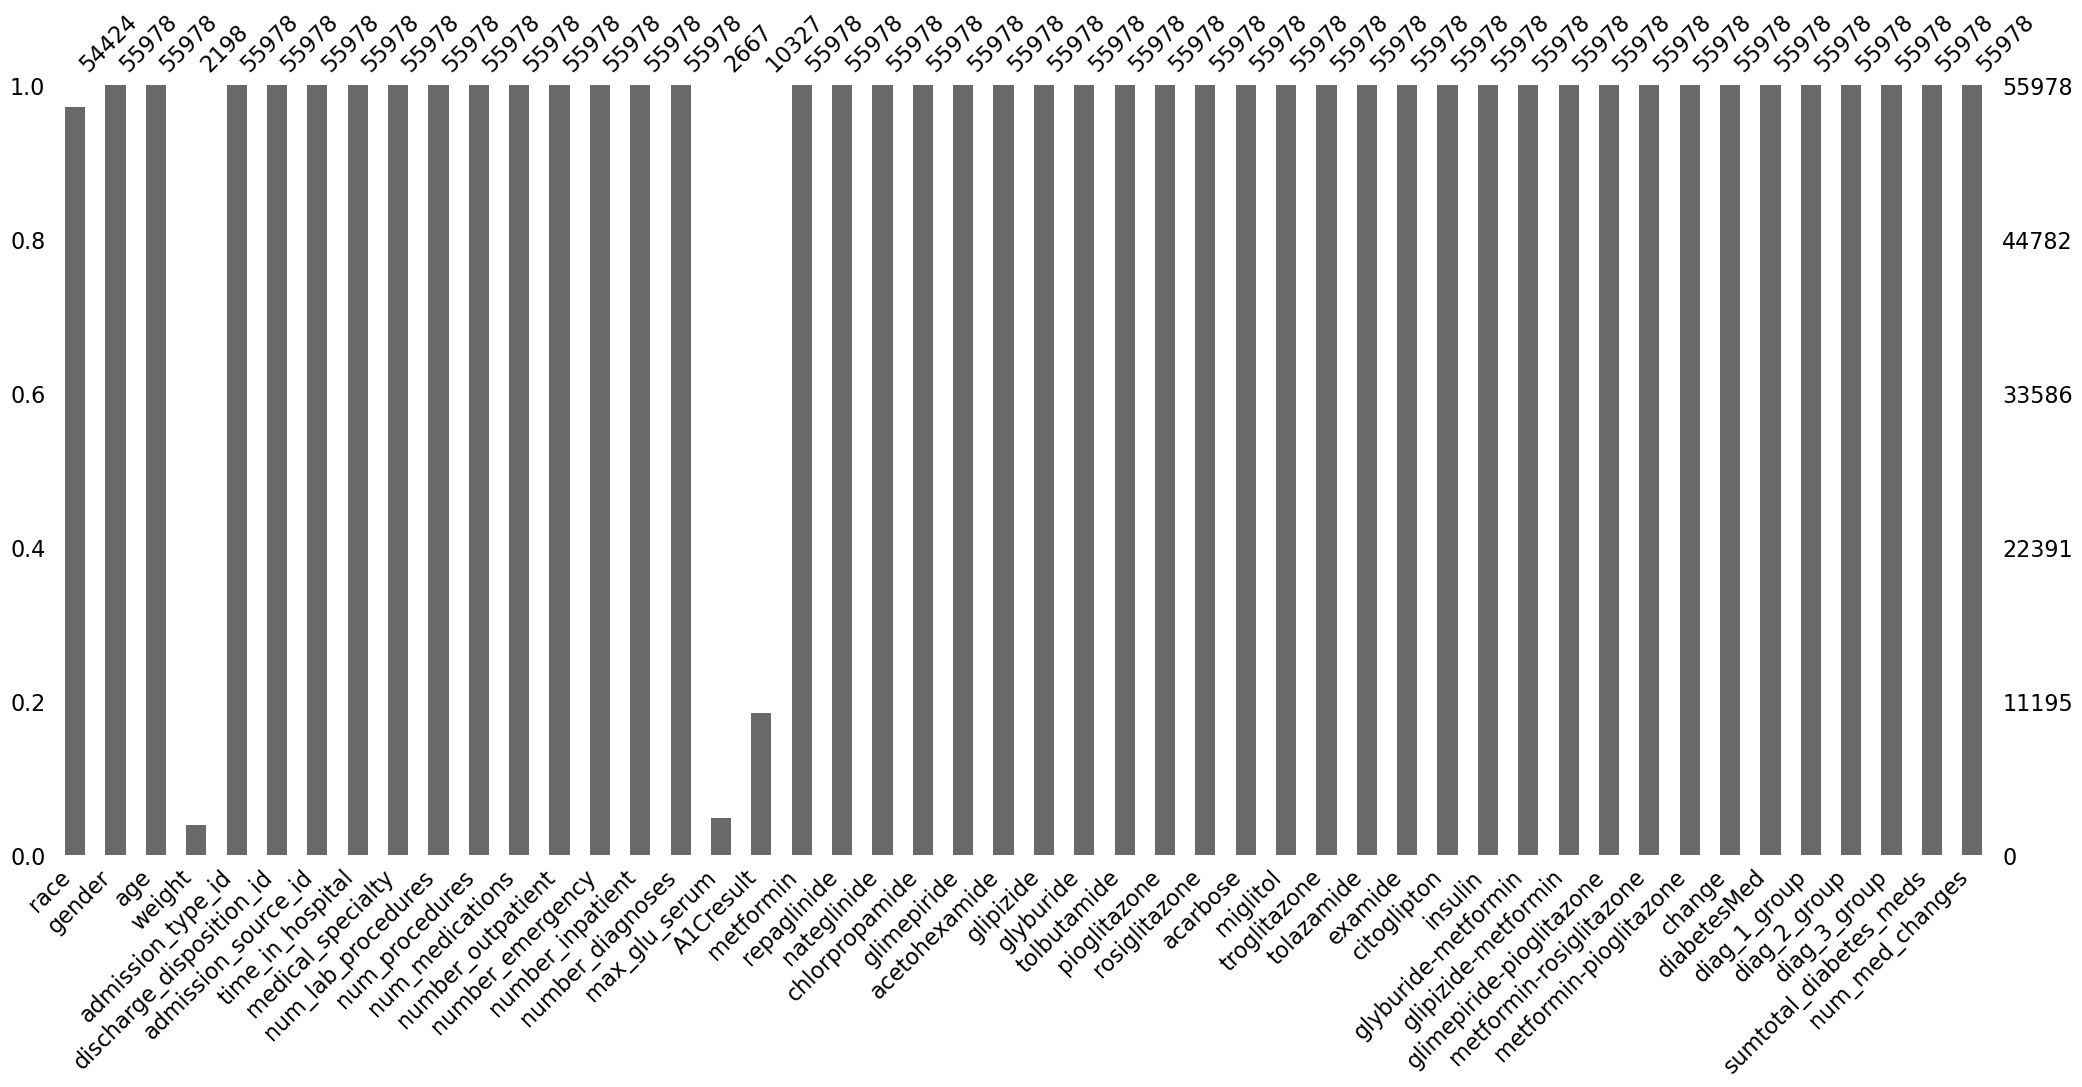

In [27]:
    #Step 2.3. EDA on X_train
            #Step2.3.1 : MISSINGNESS OF DATA
import missingno as msno
msno.bar(X_train)

missing_pct = (X_train.isnull().mean().mul(100).sort_values(ascending=False))
missing_pct
## 5. Pipeline
# -------------------------
# imputation
# rare-category handling
# encoding
# scaling
# feature selection
# model

In [28]:
        #How many patients for each drug? - determining rare features
((X_train[drug_cols] != "No").sum(axis=0)/(X_train.shape[0])*100)

metformin                   21.333381
repaglinide                  1.323734
nateglinide                  0.689557
chlorpropamide               0.101826
glimepiride                  5.271714
acetohexamide                0.001786
glipizide                   12.922934
glyburide                   10.973954
tolbutamide                  0.023223
pioglitazone                 7.440423
rosiglitazone                6.758012
acarbose                     0.289399
miglitol                     0.026796
troglitazone                 0.003573
tolazamide                   0.041088
examide                      0.000000
citoglipton                  0.000000
insulin                     51.209404
glyburide-metformin          0.707421
glipizide-metformin          0.008932
glimepiride-pioglitazone     0.000000
metformin-rosiglitazone      0.003573
metformin-pioglitazone       0.001786
dtype: float64

In [29]:
#Rare drugs : 
for col in drug_cols:
    print(X_train[col].value_counts(dropna=False))

metformin
No        44036
Steady    10929
Up          667
Down        346
Name: count, dtype: int64
repaglinide
No        55237
Steady      659
Up           60
Down         22
Name: count, dtype: int64
nateglinide
No        55592
Steady      372
Up           10
Down          4
Name: count, dtype: int64
chlorpropamide
No        55921
Steady       53
Up            3
Down          1
Name: count, dtype: int64
glimepiride
No        53027
Steady     2653
Up          189
Down        109
Name: count, dtype: int64
acetohexamide
No        55977
Steady        1
Name: count, dtype: int64
glipizide
No        48744
Steady     6472
Up          457
Down        305
Name: count, dtype: int64
glyburide
No        49835
Steady     5319
Up          493
Down        331
Name: count, dtype: int64
tolbutamide
No        55965
Steady       13
Name: count, dtype: int64
pioglitazone
No        51813
Steady     3957
Up          140
Down         68
Name: count, dtype: int64
rosiglitazone
No        52195
Steady     361

In [30]:
for col in drug_cols:
    print(X_train[col].value_counts(normalize=True, dropna=False).mul(100).round(2).sort_values())

metformin
Down       0.62
Up         1.19
Steady    19.52
No        78.67
Name: proportion, dtype: float64
repaglinide
Down       0.04
Up         0.11
Steady     1.18
No        98.68
Name: proportion, dtype: float64
nateglinide
Down       0.01
Up         0.02
Steady     0.66
No        99.31
Name: proportion, dtype: float64
chlorpropamide
Down       0.00
Up         0.01
Steady     0.09
No        99.90
Name: proportion, dtype: float64
glimepiride
Down       0.19
Up         0.34
Steady     4.74
No        94.73
Name: proportion, dtype: float64
acetohexamide
Steady      0.0
No        100.0
Name: proportion, dtype: float64
glipizide
Down       0.54
Up         0.82
Steady    11.56
No        87.08
Name: proportion, dtype: float64
glyburide
Down       0.59
Up         0.88
Steady     9.50
No        89.03
Name: proportion, dtype: float64
tolbutamide
Steady     0.02
No        99.98
Name: proportion, dtype: float64
pioglitazone
Down       0.12
Up         0.25
Steady     7.07
No        92.56
Name: p

In [31]:
#Lets drop : examide, citoglipton and glimepiride-pioglitazone, weight
X_train = X_train.drop(["weight", "examide", "citoglipton", "glimepiride-pioglitazone"], axis=1)
X_test = X_test.drop(["weight", "examide", "citoglipton", "glimepiride-pioglitazone"], axis=1)

#Note : Individual rare drug indicators are removed because they're too sparse to model independently, 
#while the aggregate medication-count feature deliberately includes all diabetes drugs.

#Handling the other "missingness" and thinking about why it's missing :
A1Cresult is especially important in this dataset. The original Strack et al. paper was specifically about HbA1c measurement and readmission, 
and the variable is defined as >8, >7, Norm, or None if the test was not measured. Importantly, "None" here is not ordinary missing data. 
It means the HbA1c test was not performed, which itself may carry useful information. So should not convert "None" to NaN and impute it.

The same applies to max_glu_serum. Its categories represent Norm, >200, >300, and None when no test was performed. So again, "None" is meaningful,
it means “serum glucose test not performed”, not “we lost the data”.

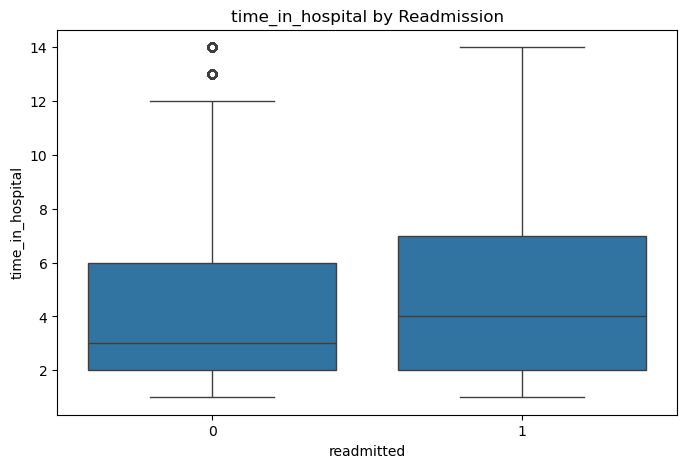

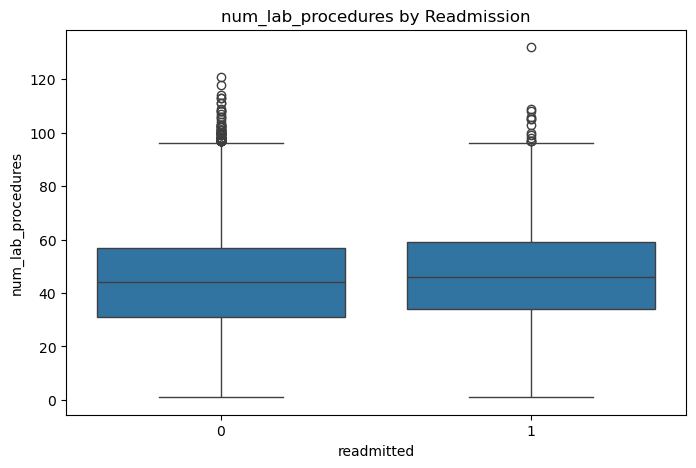

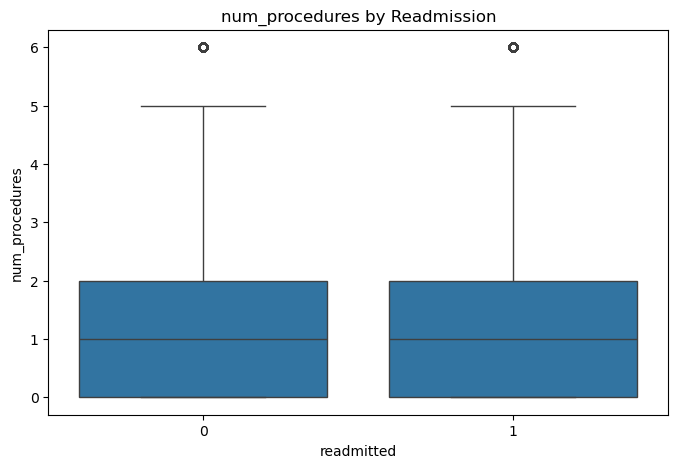

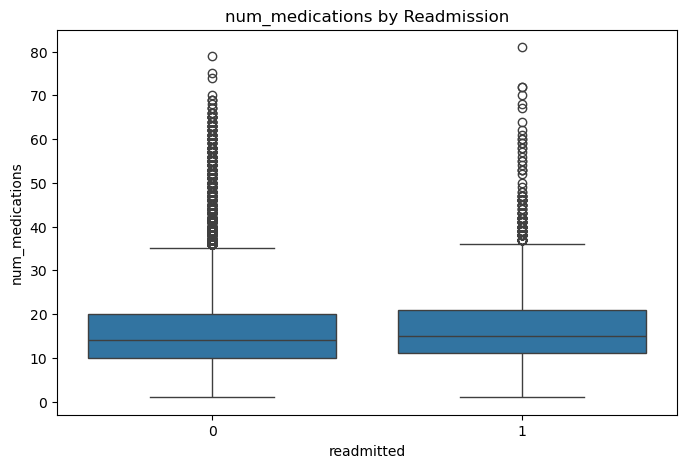

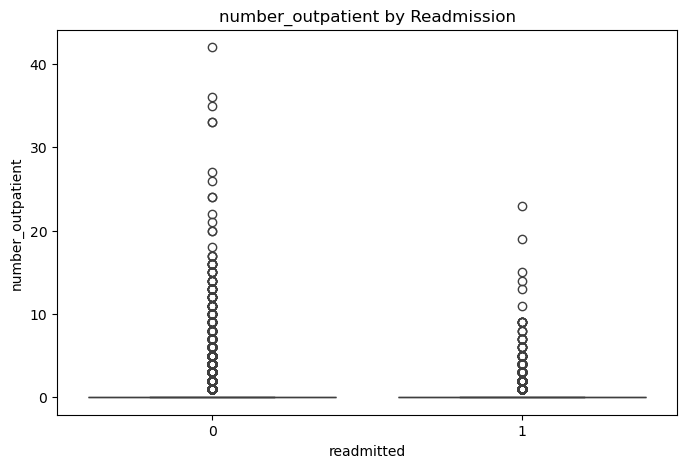

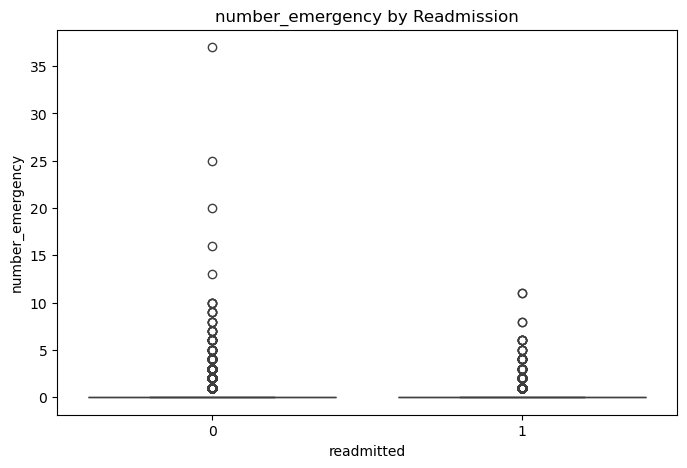

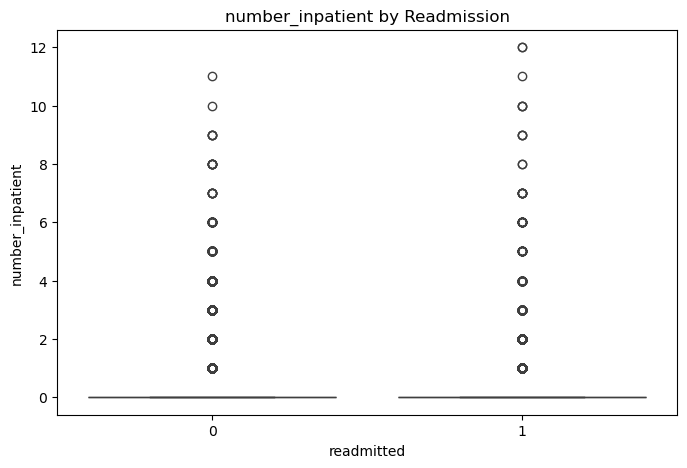

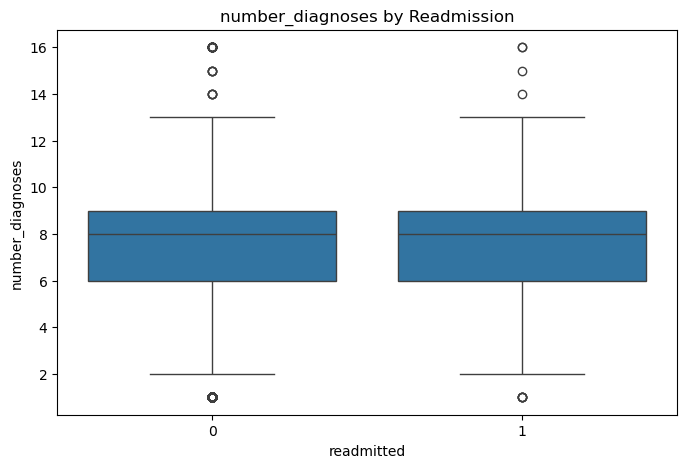

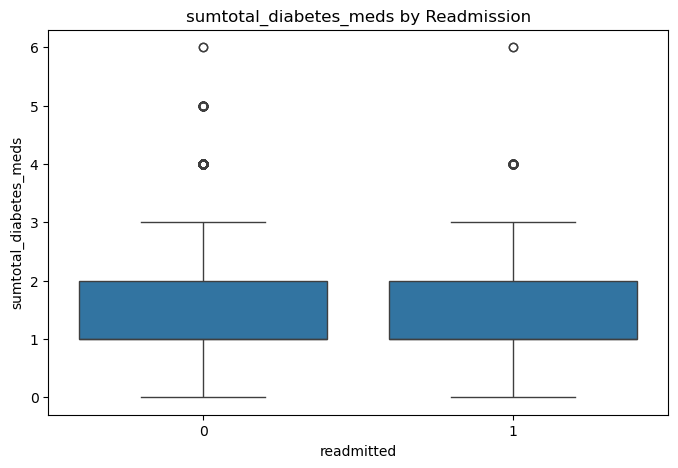

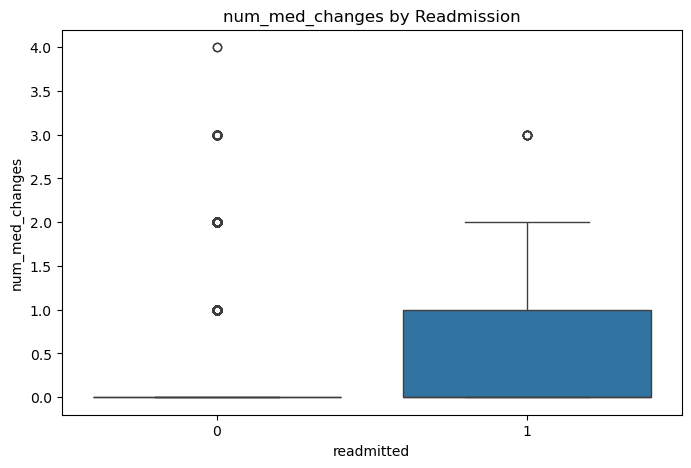

In [32]:
#STAGE 3 : EDA FOR UNDERSTANDING  DISTRIBUTIONS, RELATIONSHIPS, CLUSTERING TENDENCIES (Exploratory Data analysis for model-development)

#Step 3.1: NUMERICAL COLS
#Step 3.1.1: Boxplots to understand distributions of num cols by outcome
import seaborn as sns
import matplotlib.pyplot as plt

train_df = X_train.copy() #making a temporary combined df with training X_train + y_train
train_df["readmitted"] = y_train

numeric_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications", "number_outpatient",
                "number_emergency", "number_inpatient", "number_diagnoses", "sumtotal_diabetes_meds", "num_med_changes"]

for num in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="readmitted", y=num, data=train_df)
    plt.title(f"{num} by Readmission")
    plt.show()

In [33]:
#Median and IQR by outcome

for col in numeric_cols:
    summary = (train_df.groupby("readmitted")[col].agg(median="median", Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75)))

    summary["IQR"] = summary["Q3"] - summary["Q1"]

    print(f"\n--- {col} ---")
    print(summary.round(2))


--- time_in_hospital ---
            median   Q1   Q3  IQR
readmitted                       
0              3.0  2.0  6.0  4.0
1              4.0  2.0  7.0  5.0

--- num_lab_procedures ---
            median    Q1    Q3   IQR
readmitted                          
0             44.0  31.0  57.0  26.0
1             46.0  34.0  59.0  25.0

--- num_procedures ---
            median   Q1   Q3  IQR
readmitted                       
0              1.0  0.0  2.0  2.0
1              1.0  0.0  2.0  2.0

--- num_medications ---
            median    Q1    Q3   IQR
readmitted                          
0             14.0  10.0  20.0  10.0
1             15.0  11.0  21.0  10.0

--- number_outpatient ---
            median   Q1   Q3  IQR
readmitted                       
0              0.0  0.0  0.0  0.0
1              0.0  0.0  0.0  0.0

--- number_emergency ---
            median   Q1   Q3  IQR
readmitted                       
0              0.0  0.0  0.0  0.0
1              0.0  0.0  0.0  0.0

---

In [34]:
#Looking closely at the zero-sparse features: how common each value is in %, sorted 
for col in [
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "num_med_changes"
]:
    print(f"\n--- {col} ---")
    print(train_df[col].value_counts(normalize=True).sort_index().mul(100).round(2))
    #mul(100)=Multiply it by 100


--- number_outpatient ---
number_outpatient
0     86.98
1      6.82
2      2.83
3      1.58
4      0.81
5      0.41
6      0.16
7      0.10
8      0.07
9      0.06
10     0.04
11     0.03
12     0.02
13     0.02
14     0.01
15     0.01
16     0.01
17     0.01
18     0.00
19     0.00
20     0.00
21     0.00
22     0.00
23     0.00
24     0.00
26     0.00
27     0.00
33     0.00
35     0.00
36     0.00
42     0.00
Name: proportion, dtype: float64

--- number_emergency ---
number_emergency
0     92.72
1      5.55
2      1.11
3      0.35
4      0.14
5      0.04
6      0.04
7      0.01
8      0.01
9      0.01
10     0.01
11     0.00
13     0.00
16     0.00
20     0.00
25     0.00
37     0.00
Name: proportion, dtype: float64

--- number_inpatient ---
number_inpatient
0     88.33
1      8.24
2      2.16
3      0.65
4      0.33
5      0.14
6      0.09
7      0.02
8      0.02
9      0.01
10     0.01
11     0.00
12     0.00
Name: proportion, dtype: float64

--- num_med_changes ---
num_med_chang

In [35]:
#Looking closely at num_med_changes: what percentage of each outcome had the different number of changes.
pd.crosstab(
    train_df["num_med_changes"],
    train_df["readmitted"],
    normalize="columns"
).mul(100).round(2)

#Medication changes were somewhat more common among patients readmitted within 30 days. Approximately 26.6% of early-readmitted patients had 
#at least one diabetes medication change during the index admission, compared with 23.09% among patients who were not readmitted within 30 days. 
#This suggests medication modification may contain predictive information, although the magnitude of the unadjusted difference is modest.

readmitted,0,1
num_med_changes,,
0,75.51,71.72
1,23.09,26.60
2,1.31,1.49
3,0.09,0.18
4,0.00,0.00


In [36]:
#Looking closer at zero-inflated numeric features :

for col in ["number_outpatient", "number_emergency", "number_inpatient"]:
    train_df[f"any_{col}"] = (train_df[col] > 0).astype(int)

    display(
        pd.crosstab(
            train_df[f"any_{col}"],
            train_df["readmitted"],
            normalize="columns"
        ).mul(100).round(2)
    )


#Prior healthcare utilization was more common among patients readmitted within 30 days. The largest difference was observed for prior inpatient admissions:
#20.1% of patients readmitted within 30 days had at least one prior inpatient admission, compared with 10.8% of patients who were not readmitted within
#30 days. Smaller differences were observed for prior emergency visits (9.9% vs. 7.0%) and outpatient visits (14.7% vs. 12.9%). 
#These findings suggest that previous inpatient utilization may be an important predictor of early readmission.

readmitted,0,1
any_number_outpatient,,
0,87.15,85.28
1,12.85,14.72


readmitted,0,1
any_number_emergency,,
0,92.98,90.08
1,7.02,9.92


readmitted,0,1
any_number_inpatient,,
0,89.16,79.89
1,10.84,20.11


In [37]:
#Looking closer at any_number_outpatient/emergency/inpatient and seeing if it's a better feature than the continuos versions
#the continuous versions are highly zero-inflated

#1- any_number_outpatient vs number_outpatient
print(f"\n--- any_number_outpatient ---")

print((train_df
    .groupby("any_number_outpatient")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
))

print("\n")
print((train_df
    .groupby("number_outpatient")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
))

#2- any_number_emergency vs number_emergency
print(f"\n--- any_number_emergency ---")

print((train_df
    .groupby("any_number_emergency")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
))

print("\n")
print((train_df
    .groupby("number_emergency")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
))

#3- any_number_inpatient vs number_inpatient
print(f"\n--- any_number_inpatient ---")

print((train_df
    .groupby("any_number_inpatient")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
))

print("\n")
print((train_df
    .groupby("number_inpatient")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
))


#conclusion : 
#1-number_outpatient: this feature doesnt have much of a pattern. so any_number_outpatient may be better
#2-number_emergency : there is a sparse tail, maybe we can collapse it to just 3 categories: 0/1/2/3+
#3-number_inpatient : there is a sparse tail, maybe we can collapse it to 0/1/2/3/4+

#For For a tree model such as random forest or gradient boosting, 
#its better to leave the original counts because those algorithms can discover thresholds themselves.


--- any_number_outpatient ---
                           n  readmission_rate
any_number_outpatient                         
0                      48691          8.796287
1                       7287         10.141348


                       n  readmission_rate
number_outpatient                         
0                  48691          8.796287
1                   3817         10.322243
2                   1583         10.360076
3                    885          8.700565
4                    451         11.973392
5                    229         10.043668
6                     92          6.521739
7                     57          8.771930
8                     40          7.500000
9                     33         21.212121
10                    23          0.000000
11                    16          6.250000
12                    10          0.000000
13                    10         10.000000
14                     8         12.500000
15                     7         14.285714
16   

In [38]:
#Looking at outliers in the numeric cols

for col in numeric_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]

    print(col, "Outliers:", len(outliers), "Percentage:", round(len(outliers) / len(train_df) * 100, 2),"%")

time_in_hospital Outliers: 1113 Percentage: 1.99 %
num_lab_procedures Outliers: 87 Percentage: 0.16 %
num_procedures Outliers: 3100 Percentage: 5.54 %
num_medications Outliers: 1522 Percentage: 2.72 %
number_outpatient Outliers: 7287 Percentage: 13.02 %
number_emergency Outliers: 4076 Percentage: 7.28 %
number_inpatient Outliers: 6534 Percentage: 11.67 %
number_diagnoses Outliers: 203 Percentage: 0.36 %
sumtotal_diabetes_meds Outliers: 838 Percentage: 1.5 %
num_med_changes Outliers: 13899 Percentage: 24.83 %


Potential extreme observations were identified using the IQR rule for exploratory purposes. Clinically plausible extreme values were retained because utilization and treatment-intensity variables are naturally right-skewed and extreme values may contain meaningful predictive information.

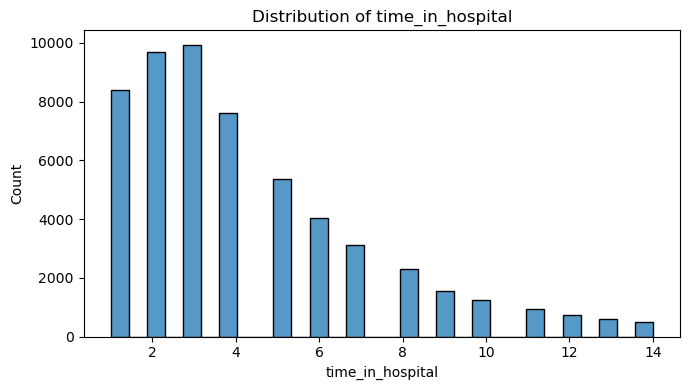

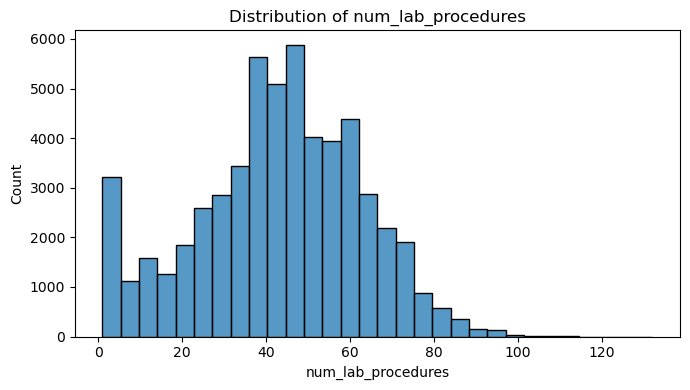

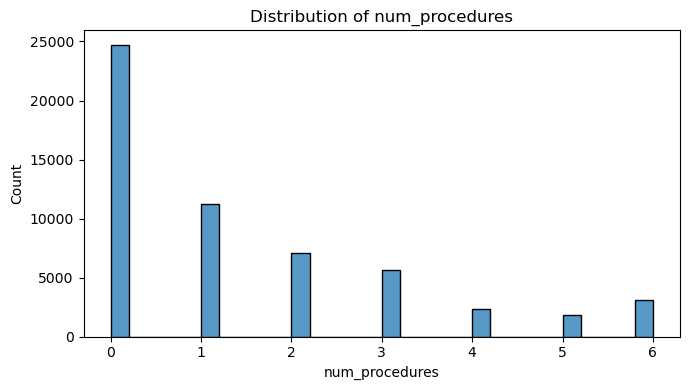

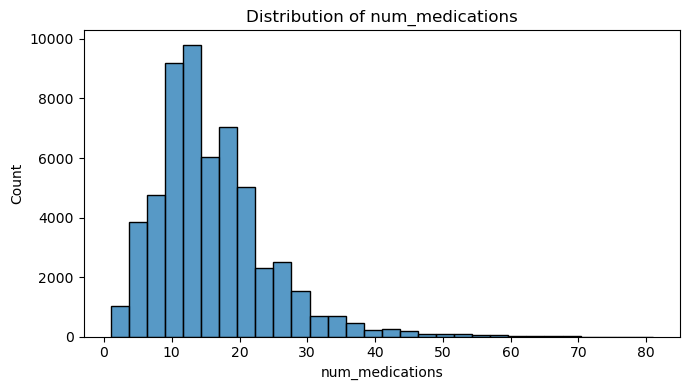

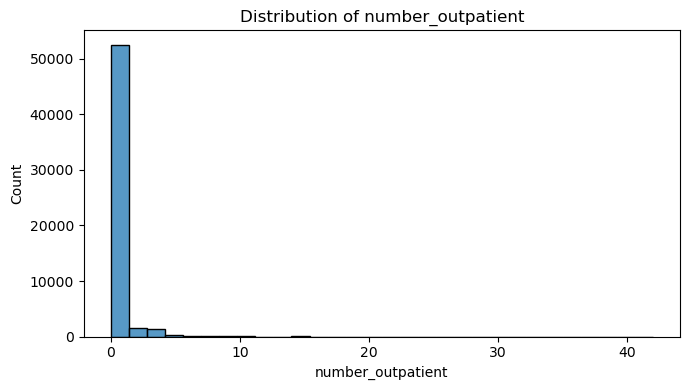

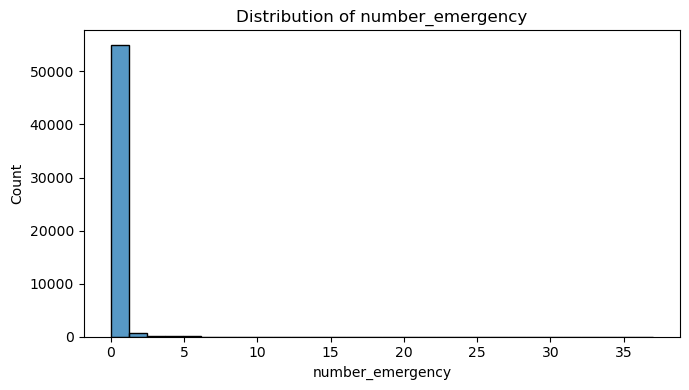

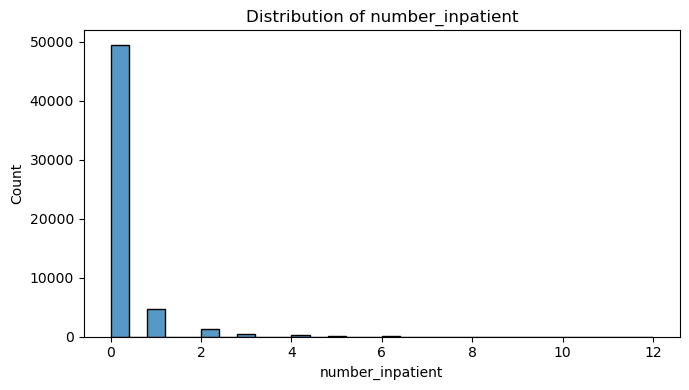

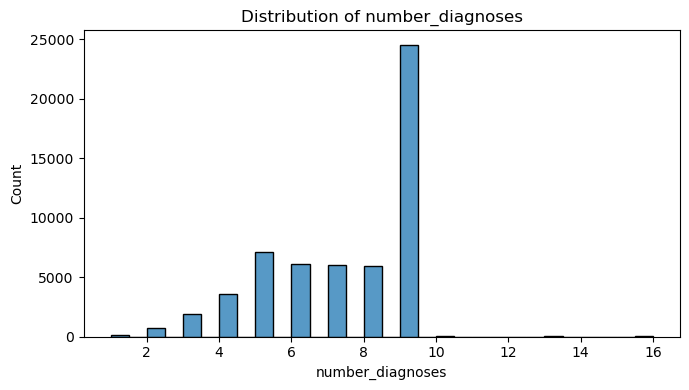

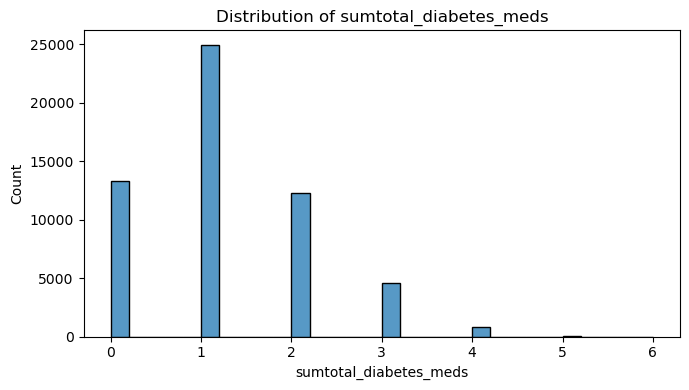

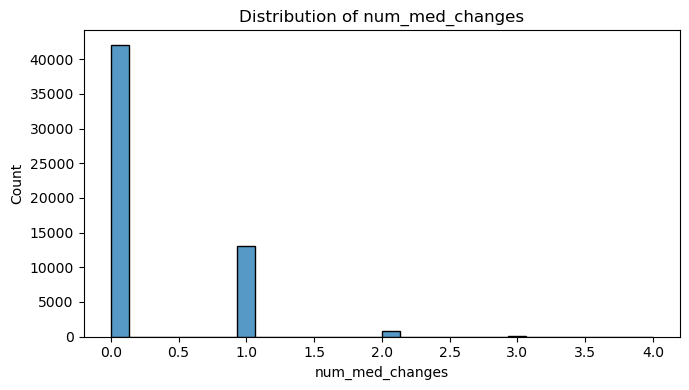

In [39]:
#Overall numeric distributions :
# Numerical variables only - explicitly defining true numerical variables so we can do distribution plot
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "sumtotal_diabetes_meds",
    "num_med_changes"
]

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(data=train_df, x=col, bins=30)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

In [40]:
#Quantifying the Skewness of the numerical cols
skewness = (train_df[numeric_cols].skew().sort_values(ascending=False))
print(skewness)

#close to 0 → fairly symmetric
#positive → right-skewed
#negative → left-skewed

number_emergency          16.899238
number_outpatient          9.858446
number_inpatient           5.659423
num_med_changes            1.585275
num_medications            1.434947
num_procedures             1.236455
time_in_hospital           1.173311
sumtotal_diabetes_meds     0.662592
num_lab_procedures        -0.215960
number_diagnoses          -0.720953
dtype: float64


In [41]:
#Note to self:
#may consider log1p for number_emergency, number_outpatient, num_medications
#may consider log transformation or categtorical binning for number_inpatient

The prior healthcare utilization variables exhibited substantial positive skew, particularly number_emergency (16.90), number_outpatient (9.86), and number_inpatient (5.66). This was primarily attributable to the high proportion of patients with no previous utilization. Among these variables, prior inpatient utilization showed the clearest difference between outcome groups, with 20.11% of patients readmitted within 30 days having at least one previous inpatient admission compared with 10.84% of patients not readmitted within 30 days. Alternative representations of number_inpatient, such as a binary indicator or grouped count, were therefore considered during feature engineering.

In [42]:
#Looking at categorical columns


id_cat_cols = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]
#These are actually categorical cols even though they are represented by numbers

other_cat_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

all_cat_cols = id_cat_cols + other_cat_cols

for cat in all_cat_cols:
    readmit_rate = (train_df.groupby(cat, observed=True, dropna=False)["readmitted"].agg(["size", "mean"]).sort_values("mean", ascending=False))
                                                                #"count" vs size: count counts only non-null values, size counts all rows regardless
    readmit_rate["Re-admission rate"] = readmit_rate["mean"] * 100

    print(f"\n--- {cat} ---")
    print(readmit_rate)

#Since all the re-admitted is encoded 1, calculating the mean and then *100 just makes it the proportion of readmitted


--- admission_type_id ---
                    size      mean  Re-admission rate
admission_type_id                                    
6                   3610  0.099169           9.916898
1                  28373  0.091989           9.198886
2                  10235  0.088422           8.842208
5                   2477  0.088413           8.841340
3                  11030  0.082865           8.286491
8                    231  0.069264           6.926407
4                      6  0.000000           0.000000
7                     16  0.000000           0.000000

--- discharge_disposition_id ---
                           size      mean  Re-admission rate
discharge_disposition_id                                    
12                            2  0.500000          50.000000
15                           31  0.451613          45.161290
28                           70  0.300000          30.000000
22                         1127  0.255546          25.554570
5                           738  

In [43]:
#Frequency for each value_count within each category

for cat in all_cat_cols:

    freq = (
        train_df[cat]
        .value_counts(dropna=False)
        .to_frame("count")
    )

    freq["percent"] = (
        train_df[cat]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
    )

    print(f"\n--- {cat} ---")
    print(freq.round(2))


--- admission_type_id ---
                   count  percent
admission_type_id                
1                  28373    50.69
3                  11030    19.70
2                  10235    18.28
6                   3610     6.45
5                   2477     4.42
8                    231     0.41
7                     16     0.03
4                      6     0.01

--- discharge_disposition_id ---
                          count  percent
discharge_disposition_id                
1                         35414    63.26
3                          7046    12.59
6                          6623    11.83
18                         1997     3.57
2                          1247     2.23
22                         1127     2.01
5                           738     1.32
25                          614     1.10
4                           437     0.78
7                           325     0.58
23                          206     0.37
28                           70     0.13
8                        

In [44]:
for cat in all_cat_cols:

    pct = (train_df[cat].value_counts(normalize=True, dropna=False).mul(100).sort_values())

    rare = pct[pct < 1]

    if len(rare) > 0:
        print(f"\nRare categories in {cat} (<1%):")
        print(rare.round(2))


Rare categories in admission_type_id (<1%):
admission_type_id
4    0.01
7    0.03
8    0.41
Name: proportion, dtype: float64

Rare categories in discharge_disposition_id (<1%):
discharge_disposition_id
27    0.00
12    0.00
16    0.01
10    0.01
17    0.01
9     0.01
24    0.04
15    0.06
8     0.10
28    0.13
23    0.37
7     0.58
4     0.78
Name: proportion, dtype: float64

Rare categories in admission_source_id (<1%):
admission_source_id
11    0.00
13    0.00
25    0.00
14    0.00
22    0.01
10    0.01
8     0.02
9     0.14
3     0.20
20    0.22
5     0.76
Name: proportion, dtype: float64

Rare categories in race (<1%):
race
Asian    0.71
Name: proportion, dtype: float64

Rare categories in gender (<1%):
gender
Unknown/Invalid    0.0
Name: proportion, dtype: float64

Rare categories in age (<1%):
age
[0-10)     0.22
[10-20)    0.77
Name: proportion, dtype: float64

Rare categories in metformin (<1%):
metformin
Down    0.62
Name: proportion, dtype: float64

Rare categories in repagl

In [45]:
#Medication feature EDA
for drug in drug_cols:

    if drug not in train_df.columns:
        continue

    print(f"\n--- {drug} ---")

    result = (train_df.groupby(drug, observed=True)["readmitted"].agg(patients="size", readmission_rate="mean"))
    result["readmission_rate"] = result["readmission_rate"]* 100

    print(result)


--- metformin ---
           patients  readmission_rate
metformin                            
Down            346         10.693642
No            44036          9.178854
Steady        10929          8.216671
Up              667          6.746627

--- repaglinide ---
             patients  readmission_rate
repaglinide                            
Down               22          0.000000
No              55237          8.921556
Steady            659         12.291351
Up                 60         21.666667

--- nateglinide ---
             patients  readmission_rate
nateglinide                            
Down                4          0.000000
No              55592          8.972514
Steady            372          9.139785
Up                 10          0.000000

--- chlorpropamide ---
                patients  readmission_rate
chlorpropamide                            
Down                   1          0.000000
No                 55921          8.975161
Steady                53          5

In [46]:
#For a patient's first observed hospitalization, can I predict 30-day readmission?
#Encounters ending in death or hospice disposition were excluded because subsequent hospital 
#readmission is not an equivalent or clinically meaningful outcome for these patients.

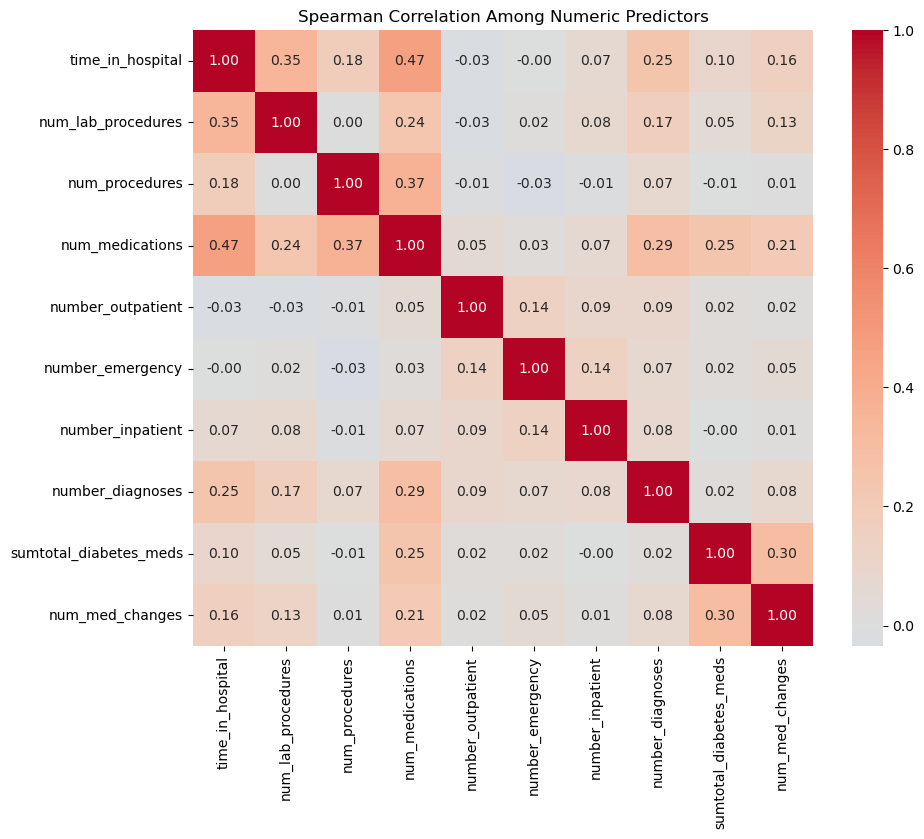

In [47]:
#checking for collinearity

numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "sumtotal_diabetes_meds",
    "num_med_changes"
]

corr_matrix = X_train[numeric_cols].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Spearman Correlation Among Numeric Predictors")
plt.show()

In [48]:
#VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_data = X_train[numeric_cols].copy()

# VIF cannot handle missing values
vif_data = vif_data.fillna(vif_data.median())

vif_data = add_constant(vif_data)

vif = pd.DataFrame({
    "feature": vif_data.columns,
    "VIF": [
        variance_inflation_factor(vif_data.values, i)
        for i in range(vif_data.shape[1])
    ]
})

vif = vif[vif["feature"] != "const"].sort_values(
    "VIF",
    ascending=False
)

print(vif)

#VIF	Interpretation
#~1	essentially no multicollinearity
#1–5	usually acceptable
#>5	worth investigating
#>10	potentially serious

                   feature       VIF
4          num_medications  1.668826
1         time_in_hospital  1.392780
3           num_procedures  1.220554
9   sumtotal_diabetes_meds  1.163208
2       num_lab_procedures  1.160106
10         num_med_changes  1.158234
8         number_diagnoses  1.108711
7         number_inpatient  1.033974
6         number_emergency  1.031537
5        number_outpatient  1.018580


In [49]:
#Each cell = number of training rows having that combination
#margins=True adds totals (All)

pd.crosstab(
    X_train["change"],
    X_train["num_med_changes"],
    margins=True
)

#Some notes: when num_med_changes=0, "change" is still capturing 11,365 changes. 
#So my engineered feature is not capturing every type of change (it only measures up and down, not in other ways it's changed)
#With this in mind these two features potentially capture distinct information.

num_med_changes,0,1,2,3,4,All
change,,,,,,
Ch,11365,13100,740,57,2,25264
No,30714,0,0,0,0,30714
All,42079,13100,740,57,2,55978


In [50]:
#num_med_changes>0 means that change = No, always
#And num_med_changes=0 means change is capturing something num_med_changes cannot
#Are they potentially multicollinear?
X_train_copy=X_train.copy()

change_binary = (X_train_copy["change"] == "Ch").astype(int) #make it binary so we can do spearman correlation

pd.DataFrame({
    "change": change_binary,
    "num_med_changes": X_train_copy["num_med_changes"]
}).corr(method="spearman")



,change,num_med_changes
change,1.000000,0.632285
num_med_changes,0.632285,1.000000


In [51]:
#VIF between the two features
from statsmodels.stats.outliers_influence import variance_inflation_factor

check_df = pd.DataFrame({
    "change": (X_train_copy["change"] == "Ch").astype(int),
    "num_med_changes": X_train_copy["num_med_changes"]
})

vif = pd.DataFrame({
    "feature": check_df.columns,
    "VIF": [
        variance_inflation_factor(check_df.values, i)
        for i in range(check_df.shape[1])
    ]
})

vif

#change and num_med_changes showed moderate correlation (Spearman ρ = 0.63). 
#However, VIF = 2.08, indicating that multicollinearity was not substantial enough to require exclusion of either predictor.
#A Spearman correlation of 0.6322 means change and num_med_changes are moderately-to-strongly associated, which fits the crosstab. 
#But it is still below the common “high correlation” warning zone around |0.7|–|0.8|.

#VIF around 1 = little collinearity
#VIF 1–5 = usually acceptable
#VIF >5 = investigate more closely
#VIF >10 = often considered problematic

,feature,VIF
0,change,2.080064
1,num_med_changes,2.080064


In [52]:
#Investigating diabetesMed and sumtotal_diabetes_meds:

pd.crosstab(
    X_train["diabetesMed"],
    X_train["sumtotal_diabetes_meds"],
    margins=True
)
#It looks fully deterministic. One needs to be dropped?

sumtotal_diabetes_meds,0,1,2,3,4,5,6,All
diabetesMed,,,,,,,,
No,13311,0,0,0,0,0,0,13311
Yes,0,24948,12300,4581,797,37,4,42667
All,13311,24948,12300,4581,797,37,4,55978


In [53]:
#Does outcome change significantly for increasing number of sumtotal_diabetes_meds
(train_df
    .groupby("sumtotal_diabetes_meds")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
)

#This result favours dropping sumtotal_diabetes_meds because the readmission rate is similar for having 1-4 meds. And 5 &6 samples sizes are tiny

#diabetesMed and the engineered sumtotal_diabetes_meds feature were deterministically related, with diabetesMed = No corresponding exclusively to 
#zero diabetes medications and diabetesMed = Yes corresponding to one or more medications. Exploratory analysis showed that 30-day readmission differed 
#primarily between patients receiving no diabetes medication and those receiving any diabetes medication, while readmission rates were relatively 
#similar across patients receiving one to four diabetes medications. Therefore, the binary diabetesMed variable was retained and the medication-count 
#feature was excluded to reduce redundancy.

,n,readmission_rate
sumtotal_diabetes_meds,,
0,13311,7.580197
1,24948,9.591951
2,12300,9.235772
3,4581,9.015499
4,797,8.657465
5,37,0.000000
6,4,50.000000


In [54]:
#Final EDA decisions :
#we have previously dropped "weight", "examide", "citoglipton", "glimepiride-pioglitazone"

#1-Drop sumtotal_diabetes_meds
X_train = X_train.drop(columns=["sumtotal_diabetes_meds"])
X_test = X_test.drop(columns=["sumtotal_diabetes_meds"])

#2-Bring in any_number_outpatient to replace number_outpatient (ie make it binary) ** ORIGINAL NOT DROPPED
X_train["any_number_outpatient"] = (X_train["number_outpatient"] > 0).astype(int)
X_test["any_number_outpatient"] = (X_test["number_outpatient"] > 0).astype(int)

#2-Collapse number_emergency into 3 categories to collapse sparse tail: ** ORIGINAL NOT DROPPED
X_train["number_emergency_cat"] = (X_train["number_emergency"].clip(upper=3).astype("category"))
X_test["number_emergency_cat"] = (X_test["number_emergency"].clip(upper=3).astype("category"))

#3-Collapse number_inpatient to 4 categories to collapse sparse tail ** ORIGINAL NOT DROPPED
X_train["number_inpatient_cat"] = (X_train["number_inpatient"].clip(upper=4).astype("category"))
X_test["number_inpatient_cat"] = (X_test["number_inpatient"].clip(upper=4).astype("category"))

#4-Replace missingness in RACE :
X_train["race"] = X_train["race"].fillna("Unknown")
X_test["race"] = X_test["race"].fillna("Unknown")

#5-In Gender there are 2 patients with Uknown/invalid, lets just convert it to missing
X_train["gender"] = X_train["gender"].replace("Unknown/Invalid", np.nan)
X_test["gender"] = X_test["gender"].replace("Unknown/Invalid", np.nan)

#6-Max_glu_serum : 95% missing but it means glucose test wasnt recorded/performed, so it might be its own category. Convert it to its own category
X_train["max_glu_serum"] = (X_train["max_glu_serum"].fillna("Not_measured"))
X_test["max_glu_serum"] = (X_test["max_glu_serum"].fillna("Not_measured"))

#7-A1Cresult : make Nan its own category:
X_train["A1Cresult"] = X_train["A1Cresult"].fillna("Not_measured")
X_test["A1Cresult"] = X_test["A1Cresult"].fillna("Not_measured")

#8-Medication EDA:
rare_drugs_to_drop = ["acetohexamide", "tolbutamide", "acarbose", "miglitol", "troglitazone", "tolazamide", "glyburide-metformin",
    "glipizide-metformin", "metformin-rosiglitazone", "metformin-pioglitazone"]

X_train = X_train.drop(columns=rare_drugs_to_drop)
X_test = X_test.drop(columns=rare_drugs_to_drop)


#9 - Collapse "up" and "down" to just "changed" for glimerpiride, pioglitazone, rosiglitazone
retained_drugs = ["metformin", "repaglinide", "nateglinide", "glimepiride", "glipizide", "glyburide", "pioglitazone", "rosiglitazone", "insulin"]

def standardize_med_status(x): 
    if x in ["Up", "Down"]:
        return "Changed"
    return x

for col in retained_drugs:
    X_train[col] = X_train[col].apply(standardize_med_status)
    X_test[col] = X_test[col].apply(standardize_med_status)

#To ensure consistent representation across medication classes and reduce instability arising from sparse Up and Down categories, medication status was 
#standardized as No, Steady, or Changed, with Up and Down combined into a single Changed category. Medications with extremely low overall exposure were
#excluded.

In [55]:
#Checkpoint before model development

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

print("\nOutcome prevalence - train:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nOutcome prevalence - test:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

print("\nMissing values - train:")
print(
    X_train.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(15)
)

print("\nFeature count:", X_train.shape[1])

print(X_train.columns)

Training observations: 55978
Test observations: 13995

Outcome prevalence - train:
readmitted
0    91.03
1     8.97
Name: proportion, dtype: float64

Outcome prevalence - test:
readmitted
0    91.03
1     8.97
Name: proportion, dtype: float64

Missing values - train:
gender                      0.003573
race                        0.000000
age                         0.000000
admission_type_id           0.000000
discharge_disposition_id    0.000000
admission_source_id         0.000000
time_in_hospital            0.000000
medical_specialty           0.000000
num_lab_procedures          0.000000
num_procedures              0.000000
num_medications             0.000000
number_outpatient           0.000000
number_emergency            0.000000
number_inpatient            0.000000
number_diagnoses            0.000000
dtype: float64

Feature count: 36
Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'medi